## 1. Import Libraries

In [1]:
import os
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)


## 2. Dataset Loading — exactly once

In [2]:
if Path("titanic.csv").exists():
    df = pd.read_csv("titanic.csv")
    dataset_source = "local titanic.csv cache"
else:
    df = sns.load_dataset("titanic")
    df.to_csv("titanic.csv", index=False)
    dataset_source = "Seaborn network/cache"

print("Dataset source:", dataset_source)
print("Shape:", df.shape)
display(df.head())

Dataset source: Seaborn network/cache
Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### Required offline dataset artifact

In [3]:
df.to_csv("titanic.csv", index=False)
print("titanic.csv created:", Path("titanic.csv").exists())

titanic.csv created: True


## 3. Initial Data Inspection

In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
display(df.dtypes.to_frame("dtype"))
print("\nSummary statistics:")
display(df.describe(include="all").T)

Shape: (891, 15)

Columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Data types:


,dtype
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object



Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Missing Values and Percentage-Based Strategy

In [5]:
missing_summary = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (df.isna().sum() / len(df) * 100).round(2)
})
missing_summary = missing_summary[missing_summary["Missing_Count"] > 0].sort_values(
    "Missing_Percentage", ascending=False
)

print("All affected columns:")
display(missing_summary)

All affected columns:


,Missing_Count,Missing_Percentage
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


In [6]:
missing_strategy = pd.DataFrame({
    "Column": ["deck", "age", "embarked", "embark_town"],
    "Missing_Percentage": [
        missing_summary.loc["deck", "Missing_Percentage"],
        missing_summary.loc["age", "Missing_Percentage"],
        missing_summary.loc["embarked", "Missing_Percentage"],
        missing_summary.loc["embark_town", "Missing_Percentage"]
    ],
    "Rule": [
        ">50% -> drop",
        "<=50% -> impute numeric with training median",
        "<=50% -> impute categorical with training mode",
        "<=50% -> impute categorical with training mode; not used as a model feature"
    ],
    "Decision": [
        "Drop from modeling data",
        "Median imputation inside preprocessing pipeline",
        "Most-frequent imputation inside preprocessing pipeline",
        "Most-frequent imputation if used; excluded from modeling because embarked is retained instead"
    ]
})
display(missing_strategy)

,Column,Missing_Percentage,Rule,Decision
0,deck,77.22,>50% -> drop,Drop from modeling data
1,age,19.87,<=50% -> impute numeric with training median,Median imputation inside preprocessing pipeline
2,embarked,0.22,<=50% -> impute categorical with training mode,Most-frequent imputation inside preprocessing ...
3,embark_town,0.22,<=50% -> impute categorical with training mode...,Most-frequent imputation if used; excluded fro...


## 5. Prepare Modeling Data Without Pre-Split Imputation

In [7]:
df_model = df.drop(columns=["deck"]).copy()

X = df_model.drop(columns=["survived", "alive", "class", "embark_town", "who", "adult_male"])
y = df_model["survived"].copy()

print("Model features:", X.columns.tolist())
print("Target distribution (%):")
display((y.value_counts(normalize=True) * 100).round(2).rename("percentage"))

Model features: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone']
Target distribution (%):


,percentage
survived,
0,61.62
1,38.38


## 6. EDA — IQR Outlier Counts

In [8]:
def iqr_outlier_summary(series):
    clean = series.dropna()
    q1 = clean.quantile(0.25)
    q3 = clean.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((clean < lower) | (clean > upper)).sum()
    return {
        "Q1": q1, "Q3": q3, "IQR": iqr,
        "Lower_Bound": lower, "Upper_Bound": upper,
        "Outlier_Count": int(count)
    }

age_iqr = iqr_outlier_summary(df["age"])
fare_iqr = iqr_outlier_summary(df["fare"])

iqr_results = pd.DataFrame([
    {"Variable": "age", **age_iqr},
    {"Variable": "fare", **fare_iqr}
])
display(iqr_results.round(4))

,Variable,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,age,20.1250,38.0,17.8750,-6.6875,64.8125,11
1,fare,7.9104,31.0,23.0896,-26.7240,65.6344,116


## 7. EDA — Fare Skewness: Mean vs Median vs Mode

In [9]:
fare_mean = df["fare"].mean()
fare_median = df["fare"].median()
fare_mode = df["fare"].mode().iloc[0]
fare_skew = df["fare"].skew()

print(f"Fare mean   : {fare_mean:.4f}")
print(f"Fare median : {fare_median:.4f}")
print(f"Fare mode   : {fare_mode:.4f}")
print(f"Fare skewness: {fare_skew:.4f}")

if fare_mean > fare_median > fare_mode:
    skew_conclusion = "Fare is positively/right-skewed: mean > median > mode."
elif fare_mean < fare_median < fare_mode:
    skew_conclusion = "Fare is negatively/left-skewed: mean < median < mode."
else:
    skew_conclusion = "The mean, median and mode do not form a simple monotonic skewness pattern; inspect the distribution alongside the skewness statistic."

print("Conclusion:", skew_conclusion)

Fare mean   : 32.2042
Fare median : 14.4542
Fare mode   : 8.0500
Fare skewness: 4.7873
Conclusion: Fare is positively/right-skewed: mean > median > mode.


## 8. EDA — Basic Distributions

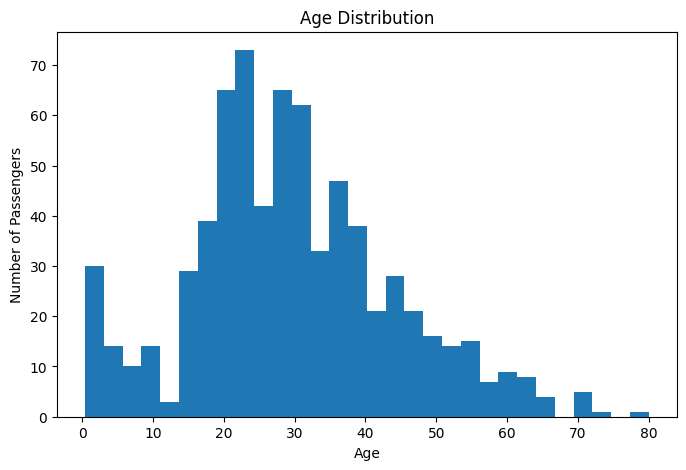

Interpretation: Age is concentrated around younger and middle-age passengers, with fewer observations at older ages. Missing ages are intentionally retained here and handled only inside model pipelines.


In [10]:
plt.figure(figsize=(8, 5))
plt.hist(df["age"].dropna(), bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()
print("Interpretation: Age is concentrated around younger and middle-age passengers, with fewer observations at older ages. Missing ages are intentionally retained here and handled only inside model pipelines.")


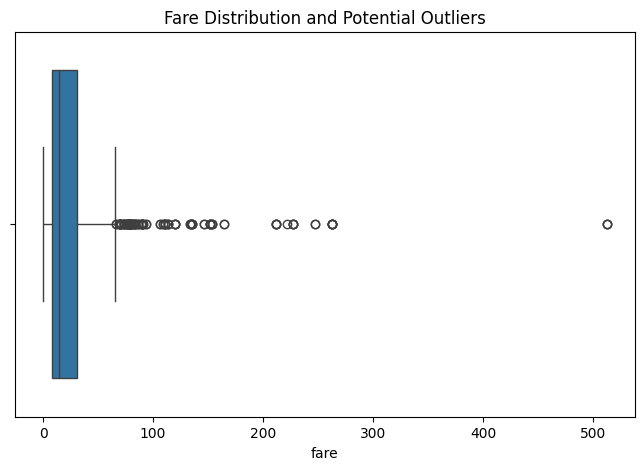

Interpretation: Fare has a long upper tail and several high-value observations, consistent with the positive skewness and IQR outlier analysis.


In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="fare", ax=ax)
ax.set_title("Fare Distribution and Potential Outliers")
plt.show()
print("Interpretation: Fare has a long upper tail and several high-value observations, consistent with the positive skewness and IQR outlier analysis.")


## 9. EDA — Numeric Survival Rates

In [12]:
sex_survival = df.groupby("sex", observed=True)["survived"].mean().mul(100).round(2)
pclass_survival = df.groupby("pclass", observed=True)["survived"].mean().mul(100).round(2)
sex_pclass_survival = (
    df.groupby(["sex", "pclass"], observed=True)["survived"]
      .mean().mul(100).round(2).reset_index(name="Survival_Rate_Percent")
)

print("Survival rate by sex (%):")
display(sex_survival.rename("Survival_Rate_Percent").to_frame())
print("Survival rate by pclass (%):")
display(pclass_survival.rename("Survival_Rate_Percent").to_frame())
print("Survival rate by sex + pclass (%):")
display(sex_pclass_survival)

Survival rate by sex (%):


,Survival_Rate_Percent
sex,
female,74.20
male,18.89


Survival rate by pclass (%):


,Survival_Rate_Percent
pclass,
1,62.96
2,47.28
3,24.24


Survival rate by sex + pclass (%):


,sex,pclass,Survival_Rate_Percent
0,female,1,96.81
1,female,2,92.11
2,female,3,50.00
3,male,1,36.89
4,male,2,15.74
5,male,3,13.54


## 10. EDA — Exact Correlation Matrix Required by the Rubric

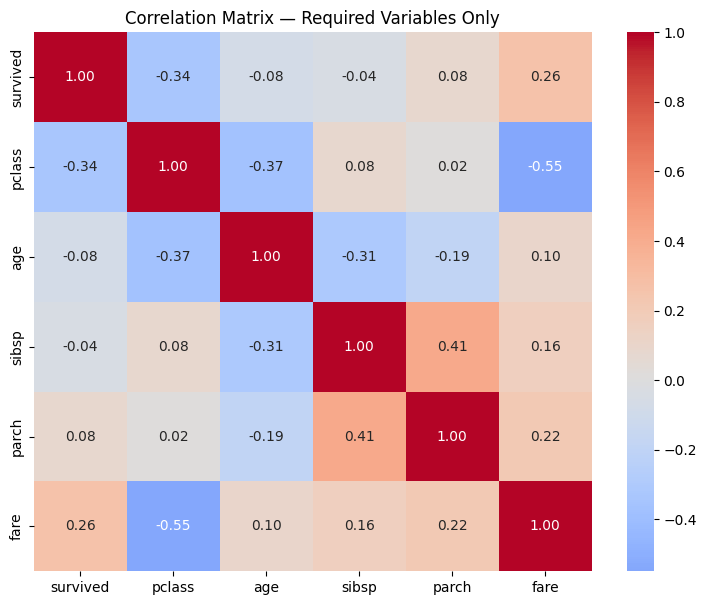

Two strongest absolute off-diagonal correlations:
- pclass vs fare: r = -0.549 (negative).
- sibsp vs parch: r = 0.415 (positive).
Interpretation: These are linear associations, not evidence of causation. adult_male and alone are intentionally excluded from this matrix as required.


In [13]:
corr_columns = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
corr_df = df[corr_columns].copy()
corr_matrix = corr_df.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix — Required Variables Only")
plt.show()

# Find the two strongest absolute off-diagonal correlations.
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
pairs = upper.stack().sort_values(key=lambda s: s.abs(), ascending=False)
top_two = pairs.head(2)

print("Two strongest absolute off-diagonal correlations:")
for (a, b), value in top_two.items():
    direction = "positive" if value > 0 else "negative"
    print(f"- {a} vs {b}: r = {value:.3f} ({direction}).")

print("Interpretation: These are linear associations, not evidence of causation. adult_male and alone are intentionally excluded from this matrix as required.")

## 11. EDA — Four Multivariate Charts

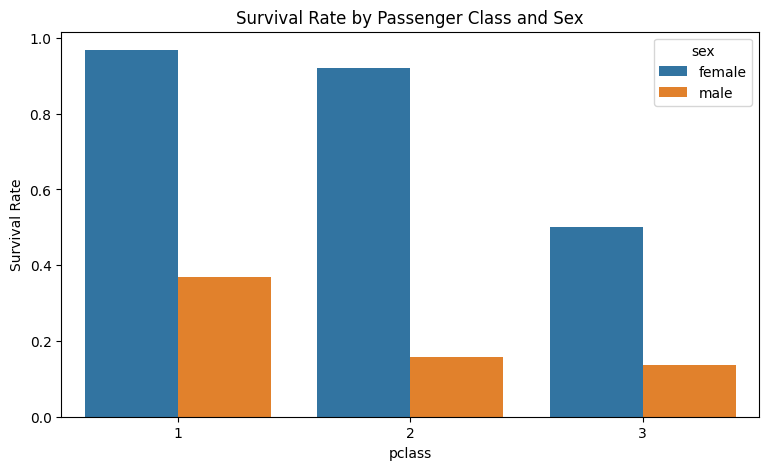

Interpretation: Survival varies jointly by sex and passenger class; the grouped rates show why looking at sex alone or class alone can hide subgroup differences.


In [14]:
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="pclass", y="survived", hue="sex", errorbar=None)
plt.title("Survival Rate by Passenger Class and Sex")
plt.ylabel("Survival Rate")
plt.show()
print("Interpretation: Survival varies jointly by sex and passenger class; the grouped rates show why looking at sex alone or class alone can hide subgroup differences.")

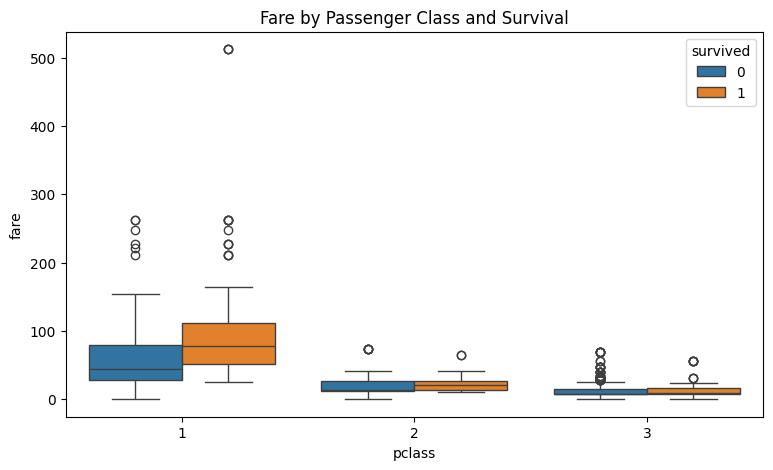

Interpretation: Fare distributions differ strongly by class, while survival groups within each class also show different fare patterns. This is a multivariable view of fare, class and survival.


In [15]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="pclass", y="fare", hue="survived")
plt.title("Fare by Passenger Class and Survival")
plt.show()
print("Interpretation: Fare distributions differ strongly by class, while survival groups within each class also show different fare patterns. This is a multivariable view of fare, class and survival.")

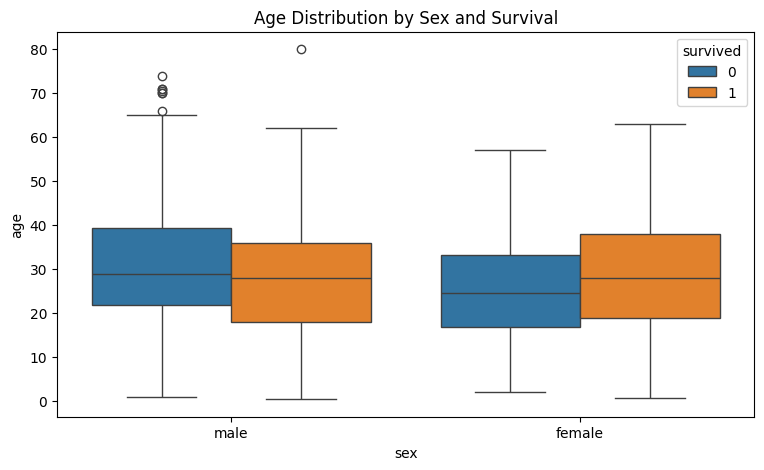

Interpretation: Age distributions differ across sex and survival groups, giving a multivariate view of age, sex and survival rather than examining each variable separately.


In [16]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="sex", y="age", hue="survived")
plt.title("Age Distribution by Sex and Survival")
plt.show()
print("Interpretation: Age distributions differ across sex and survival groups, giving a multivariate view of age, sex and survival rather than examining each variable separately.")

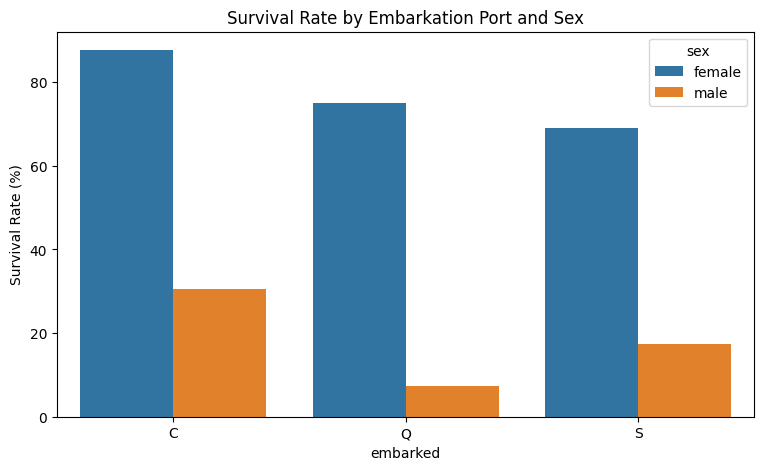

Interpretation: Survival rates vary across embarkation ports and sex categories, illustrating how two categorical variables can jointly describe differences in survival.


In [17]:
embarked_sex = df.groupby(["embarked", "sex"], observed=True)["survived"].mean().mul(100).reset_index()
plt.figure(figsize=(9, 5))
sns.barplot(data=embarked_sex, x="embarked", y="survived", hue="sex", errorbar=None)
plt.title("Survival Rate by Embarkation Port and Sex")
plt.ylabel("Survival Rate (%)")
plt.show()
print("Interpretation: Survival rates vary across embarkation ports and sex categories, illustrating how two categorical variables can jointly describe differences in survival.")

## 12. Stratified Train/Test Split — Before Any Model Preprocessing

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Training target distribution (%):")
display((y_train.value_counts(normalize=True) * 100).round(2))
print("Test target distribution (%):")
display((y_test.value_counts(normalize=True) * 100).round(2))

X_train: (712, 8)
X_test : (179, 8)
Training target distribution (%):


,proportion
survived,
0,61.66
1,38.34


Test target distribution (%):


,proportion
survived,
0,61.45
1,38.55


## 13. Leakage-Safe Preprocessing

In [19]:
numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]
categorical_features = ["sex", "embarked", "alone"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing is fit inside each model pipeline using training data only.")

Preprocessing is fit inside each model pipeline using training data only.


## 14. Standardization Check — Before vs After

In [20]:
standardization_demo = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

train_numeric_raw = X_train[["age", "fare"]].copy()
train_numeric_scaled = standardization_demo.fit_transform(train_numeric_raw)
train_numeric_scaled = pd.DataFrame(train_numeric_scaled, columns=["age", "fare"], index=X_train.index)

standardization_check = pd.DataFrame({
    "Age_Before_Mean": [train_numeric_raw["age"].mean()],
    "Age_Before_Std": [train_numeric_raw["age"].std(ddof=0)],
    "Age_After_Mean": [train_numeric_scaled["age"].mean()],
    "Age_After_Std": [train_numeric_scaled["age"].std(ddof=0)],
    "Fare_Before_Mean": [train_numeric_raw["fare"].mean()],
    "Fare_Before_Std": [train_numeric_raw["fare"].std(ddof=0)],
    "Fare_After_Mean": [train_numeric_scaled["fare"].mean()],
    "Fare_After_Std": [train_numeric_scaled["fare"].std(ddof=0)]
})
display(standardization_check.round(4))
print("Interpretation: After training-only imputation and standardization, age and fare have means approximately 0 and standard deviations approximately 1 on the training data.")

,Age_Before_Mean,Age_Before_Std,Age_After_Mean,Age_After_Std,Fare_Before_Mean,Fare_Before_Std,Fare_After_Mean,Fare_After_Std
0,29.8077,14.4726,0.0,1.0,31.8198,48.0253,-0.0,1.0


Interpretation: After training-only imputation and standardization, age and fare have means approximately 0 and standard deviations approximately 1 on the training data.


## 15. Classification Models — Logistic Regression, Decision Tree, Random Forest

In [21]:
def evaluate_classifier(name, pipeline, X_train, y_train, X_test, y_test):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    cm = confusion_matrix(y_test, y_pred)
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_test, y_prob)
    }
    print(f"\n{name}")
    print("Confusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("Accuracy :", round(metrics["Accuracy"], 4))
    print("Precision:", round(metrics["Precision"], 4))
    print("Recall   :", round(metrics["Recall"], 4))
    print("F1       :", round(metrics["F1"], 4))
    print("ROC-AUC  :", round(metrics["AUC"], 4))
    return metrics, y_pred, y_prob, cm

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42))
])

logistic_results, y_pred_logistic, y_prob_logistic, cm_logistic = evaluate_classifier(
    "Logistic Regression", logistic_pipeline, X_train, y_train, X_test, y_test
)
tree_results, y_pred_tree, y_prob_tree, cm_tree = evaluate_classifier(
    "Decision Tree", decision_tree_pipeline, X_train, y_train, X_test, y_test
)
rf_results, y_pred_rf, y_prob_rf, cm_rf = evaluate_classifier(
    "Random Forest", random_forest_pipeline, X_train, y_train, X_test, y_test
)


Logistic Regression
Confusion Matrix:
[[97 13]
 [22 47]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

Accuracy : 0.8045
Precision: 0.7833
Recall   : 0.6812
F1       : 0.7287
ROC-AUC  : 0.8501

Decision Tree
Confusion Matrix:
[[97 13]
 [20 49]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       110
           1       0.79      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179

Accuracy : 0.8156
Precision: 0.7903
Recall   : 0.7101
F1       : 0.7481
ROC-AUC  : 0.7904

Random 

## 16. Decision Tree Visualization

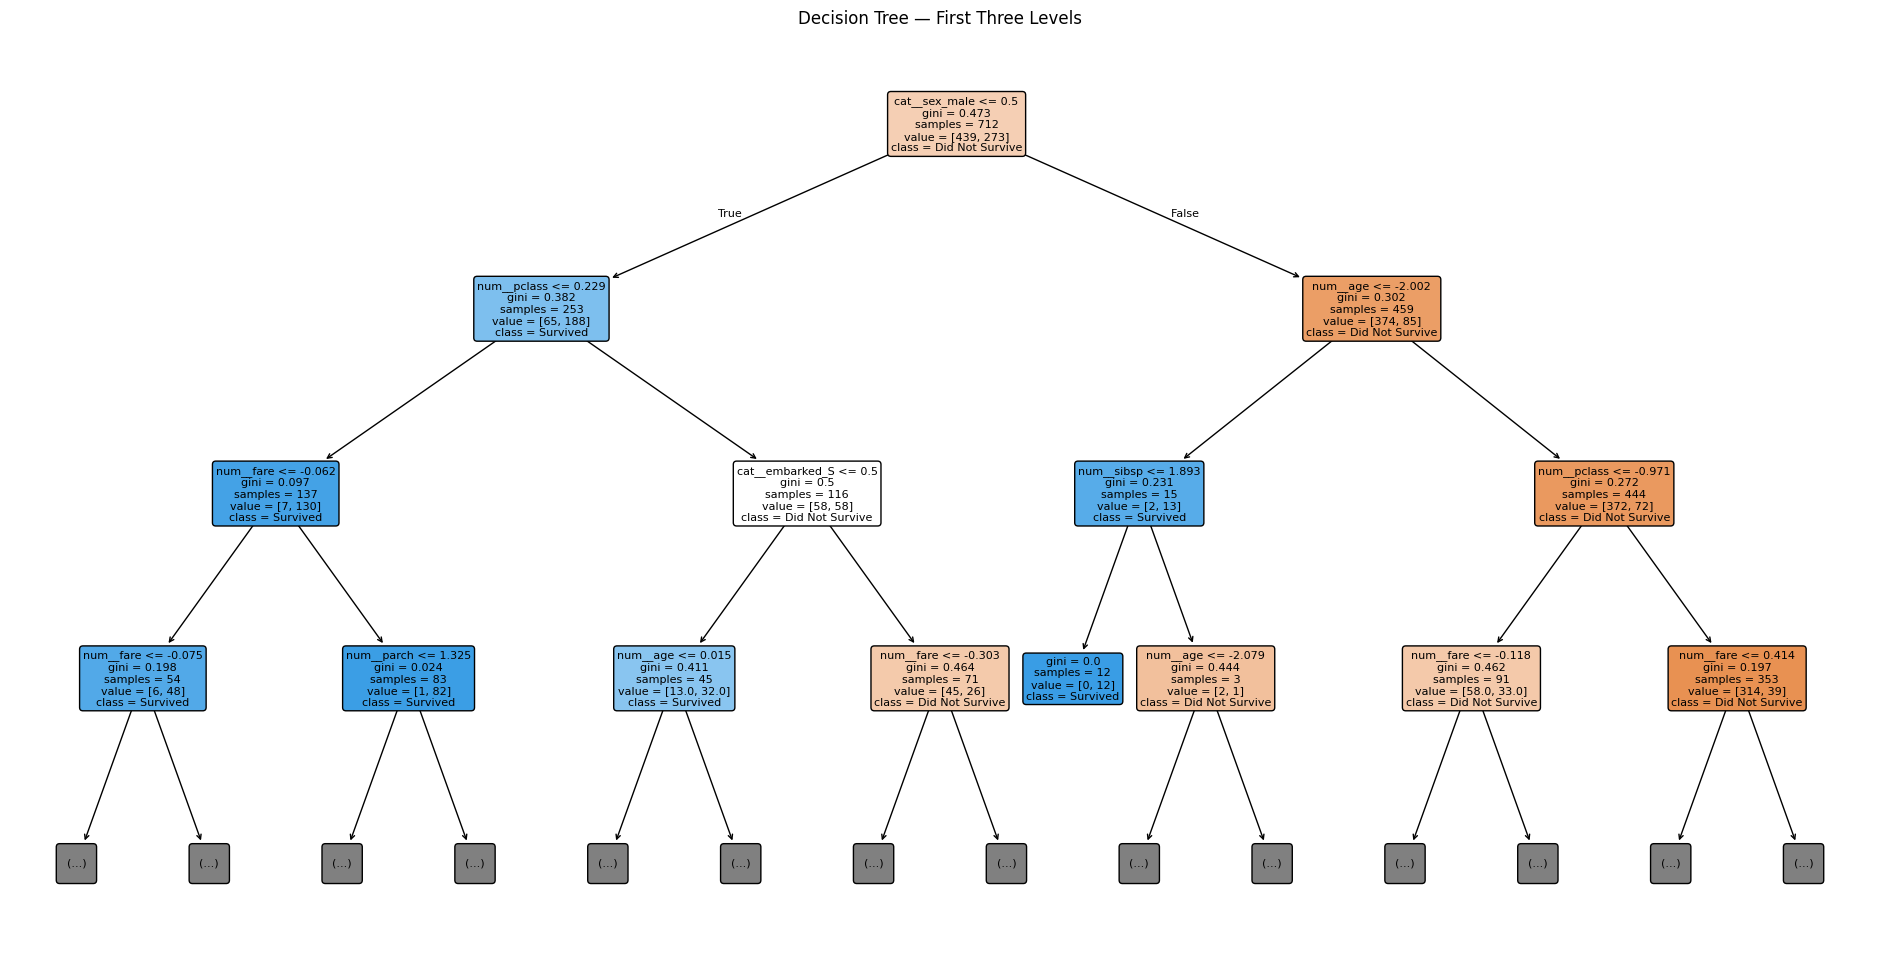

Interpretation: The plotted tree uses the encoded feature names and labeled target classes. Only the first three levels are displayed for readability; the fitted model itself is unchanged.


In [22]:
decision_tree_pipeline.fit(X_train, y_train)
tree_model = decision_tree_pipeline.named_steps["model"]
tree_preprocessor = decision_tree_pipeline.named_steps["preprocessor"]
feature_names = tree_preprocessor.get_feature_names_out()

plt.figure(figsize=(24, 12))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Did Not Survive", "Survived"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title("Decision Tree — First Three Levels")
plt.show()
print("Interpretation: The plotted tree uses the encoded feature names and labeled target classes. Only the first three levels are displayed for readability; the fitted model itself is unchanged.")

## 17. ROC Curves for All Three Classifiers

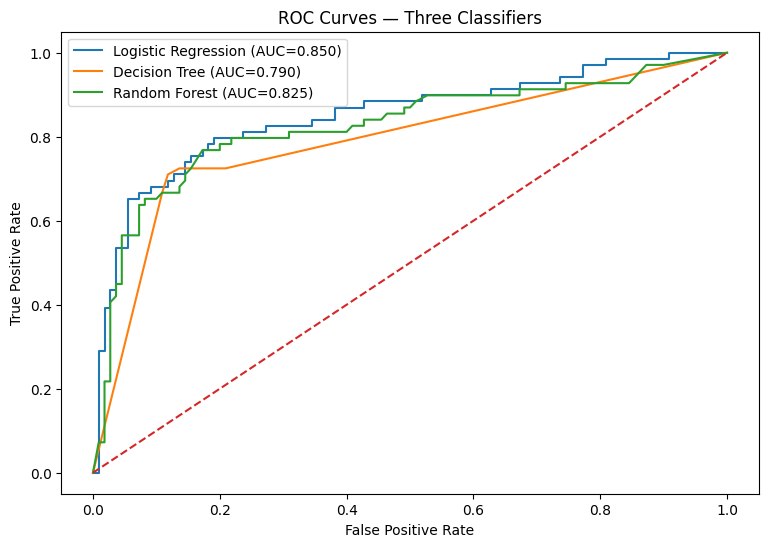

In [23]:
plt.figure(figsize=(9, 6))
for name, y_prob, result in [
    ("Logistic Regression", y_prob_logistic, logistic_results),
    ("Decision Tree", y_prob_tree, tree_results),
    ("Random Forest", y_prob_rf, rf_results)
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={result['AUC']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Three Classifiers")
plt.legend()
plt.show()

## 18. Baseline Model Comparison

In [24]:
model_comparison = pd.DataFrame([logistic_results, tree_results, rf_results])
display(model_comparison.round(4))
model_comparison.to_csv("model_comparison_baseline.csv", index=False)

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.8045,0.7833,0.6812,0.7287,0.8501
1,Decision Tree,0.8156,0.7903,0.7101,0.7481,0.7904
2,Random Forest,0.7933,0.7581,0.6812,0.7176,0.8251


## 19. Class Imbalance — Baseline vs Balanced vs SMOTE

In [25]:
baseline_rf = RandomForestClassifier(n_estimators=100, random_state=42)
baseline_rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", baseline_rf)
])
baseline_rf_pipeline.fit(X_train, y_train)
y_pred_baseline = baseline_rf_pipeline.predict(X_test)
y_prob_baseline = baseline_rf_pipeline.predict_proba(X_test)[:, 1]

balanced_rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
balanced_rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", balanced_rf)
])
balanced_rf_pipeline.fit(X_train, y_train)
y_pred_balanced = balanced_rf_pipeline.predict(X_test)
y_prob_balanced = balanced_rf_pipeline.predict_proba(X_test)[:, 1]

# SMOTE is inside an imbalanced-learn pipeline, so it is applied only to each training fold.
smote_rf_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42))
])
smote_rf_pipeline.fit(X_train, y_train)
y_pred_smote = smote_rf_pipeline.predict(X_test)
y_prob_smote = smote_rf_pipeline.predict_proba(X_test)[:, 1]

def metric_row(name, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_test, y_prob)
    }

imbalance_comparison = pd.DataFrame([
    metric_row("Baseline Random Forest", y_pred_baseline, y_prob_baseline),
    metric_row("Balanced Random Forest", y_pred_balanced, y_prob_balanced),
    metric_row("SMOTE Random Forest", y_pred_smote, y_prob_smote)
])
display(imbalance_comparison.round(4))
imbalance_comparison.to_csv("class_imbalance_comparison.csv", index=False)

,Model,Accuracy,Precision,Recall,F1,AUC
0,Baseline Random Forest,0.7933,0.7581,0.6812,0.7176,0.8251
1,Balanced Random Forest,0.8156,0.7903,0.7101,0.7481,0.8196
2,SMOTE Random Forest,0.8212,0.7846,0.7391,0.7612,0.8275


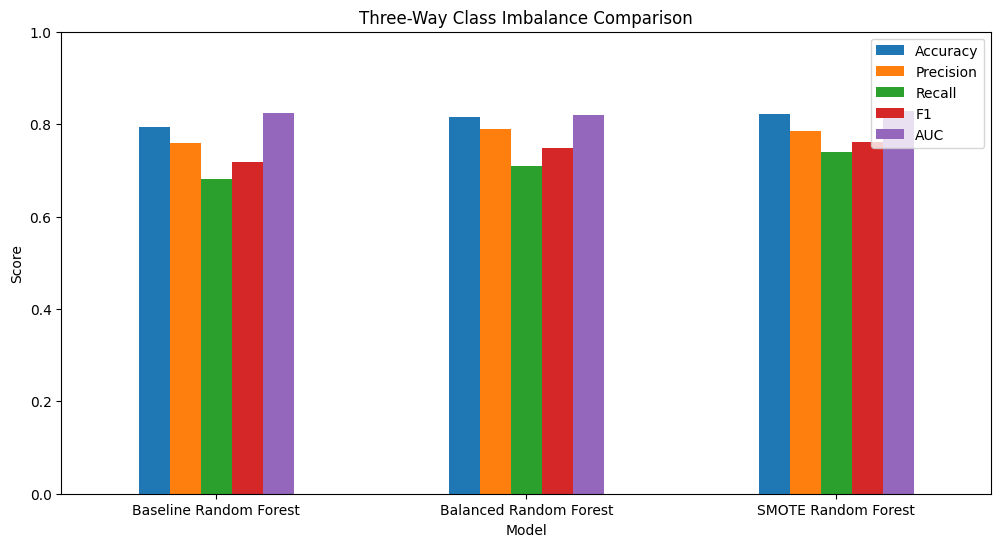

Interpretation: The three approaches are evaluated on the same untouched test split. SMOTE is applied only inside the training pipeline, so synthetic samples cannot leak into the test set.


In [26]:
imbalance_comparison.set_index("Model")[["Accuracy", "Precision", "Recall", "F1", "AUC"]].plot(
    kind="bar", figsize=(12, 6)
)
plt.title("Three-Way Class Imbalance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()
print("Interpretation: The three approaches are evaluated on the same untouched test split. SMOTE is applied only inside the training pipeline, so synthetic samples cannot leak into the test set.")

## 20. Random Forest GridSearchCV + OOB Score

In [27]:
tuned_rf = RandomForestClassifier(
    random_state=42,
    oob_score=True,
    bootstrap=True
)

tuned_rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", tuned_rf)
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=tuned_rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

best_rf_pipeline = grid_search.best_estimator_
best_rf_model = best_rf_pipeline.named_steps["model"]
oob_score = best_rf_model.oob_score_
y_pred_tuned = best_rf_pipeline.predict(X_test)
y_prob_tuned = best_rf_pipeline.predict_proba(X_test)[:, 1]

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned, zero_division=0)
tuned_recall = recall_score(y_test, y_pred_tuned, zero_division=0)
tuned_f1 = f1_score(y_test, y_pred_tuned, zero_division=0)
tuned_auc = roc_auc_score(y_test, y_prob_tuned)

print("Best Parameters:")
print(grid_search.best_params_)
print("Best CV F1:", round(grid_search.best_score_, 4))
print("OOB Score:", round(oob_score, 4))
print("\nTest metrics:")
print("Accuracy :", round(tuned_accuracy, 4))
print("Precision:", round(tuned_precision, 4))
print("Recall   :", round(tuned_recall, 4))
print("F1       :", round(tuned_f1, 4))
print("AUC      :", round(tuned_auc, 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned, zero_division=0))

Best Parameters:
{'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__n_estimators': 100}
Best CV F1: 0.7398
OOB Score: 0.8146

Test metrics:
Accuracy : 0.8045
Precision: 0.8542
Recall   : 0.5942
F1       : 0.7009
AUC      : 0.8362

Confusion Matrix:
[[103   7]
 [ 28  41]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.94      0.85       110
           1       0.85      0.59      0.70        69

    accuracy                           0.80       179
   macro avg       0.82      0.77      0.78       179
weighted avg       0.81      0.80      0.80       179



In [28]:
tuning_results = pd.DataFrame([{
    "Best_n_estimators": grid_search.best_params_["model__n_estimators"],
    "Best_max_depth": grid_search.best_params_["model__max_depth"],
    "Best_max_features": grid_search.best_params_["model__max_features"],
    "CV_F1": grid_search.best_score_,
    "Test_Accuracy": tuned_accuracy,
    "Test_Precision": tuned_precision,
    "Test_Recall": tuned_recall,
    "Test_F1": tuned_f1,
    "Test_AUC": tuned_auc,
    "OOB_Score": oob_score
}])
display(tuning_results.round(4))
tuning_results.to_csv("random_forest_tuning_results.csv", index=False)

,Best_n_estimators,Best_max_depth,Best_max_features,CV_F1,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_AUC,OOB_Score
0,100,5,sqrt,0.7398,0.8045,0.8542,0.5942,0.7009,0.8362,0.8146


## 21. Regression — Predict Fare

In [29]:
y_reg = df_model["fare"].copy()
X_reg = df_model.drop(
    columns=["fare", "survived", "alive", "class", "embark_town", "who", "adult_male"]
).copy()

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42
)

reg_numeric_features = ["pclass", "age", "sibsp", "parch"]
reg_categorical_features = ["sex", "embarked", "alone"]

reg_numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
reg_categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
reg_preprocessor = ColumnTransformer([
    ("num", reg_numeric_transformer, reg_numeric_features),
    ("cat", reg_categorical_transformer, reg_categorical_features)
])

regression_pipeline = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("model", LinearRegression())
])
regression_pipeline.fit(X_reg_train, y_reg_train)
y_reg_pred = regression_pipeline.predict(X_reg_test)

mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2 = r2_score(y_reg_test, y_reg_pred)

# Adjusted R² uses the number of predictors after preprocessing.
X_reg_test_transformed = regression_pipeline.named_steps["preprocessor"].transform(X_reg_test)
n = X_reg_test_transformed.shape[0]
p = X_reg_test_transformed.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²:", round(r2, 4))
print("Adjusted R²:", round(adjusted_r2, 4))

MAE: 20.8084
RMSE: 30.511
R²: 0.3984
Adjusted R²: 0.3588


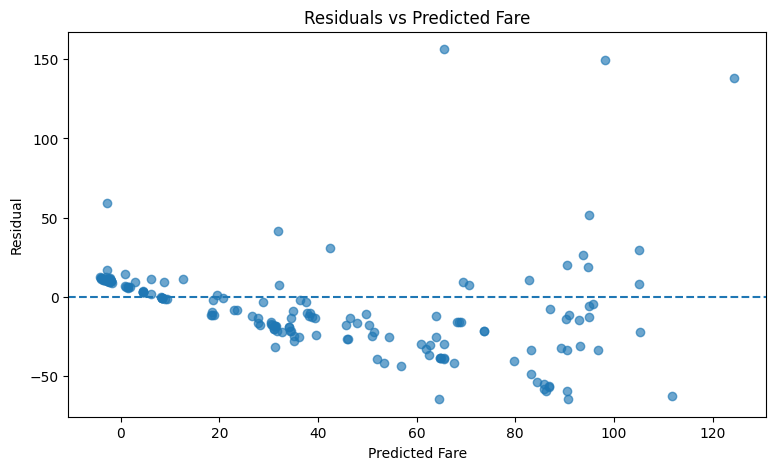

Low predicted-fare absolute-residual spread: 7.5709
High predicted-fare absolute-residual spread: 30.7192
High/low spread ratio: 4.0575
Heteroscedasticity conclusion: Evidence of heteroscedasticity: the absolute-residual spread is substantially larger for high predicted fares than for low predicted fares.


In [30]:
regression_predictions = pd.DataFrame({
    "Actual_Fare": y_reg_test.values,
    "Predicted_Fare": y_reg_pred
})

residuals = y_reg_test.to_numpy() - y_reg_pred

plt.figure(figsize=(9, 5))
plt.scatter(y_reg_pred, residuals, alpha=0.65)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Fare")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Fare")
plt.show()

predicted_series = pd.Series(y_reg_pred)
abs_residuals = pd.Series(np.abs(residuals))
low_mask = predicted_series <= predicted_series.quantile(0.33)
high_mask = predicted_series >= predicted_series.quantile(0.67)
low_spread = abs_residuals[low_mask].std()
high_spread = abs_residuals[high_mask].std()
spread_ratio = high_spread / low_spread if low_spread != 0 else np.inf

if spread_ratio > 1.20:
    hetero_conclusion = "Evidence of heteroscedasticity: the absolute-residual spread is substantially larger for high predicted fares than for low predicted fares."
else:
    hetero_conclusion = "No strong evidence of heteroscedasticity from this spread check: residual variability is not substantially larger in the high predicted-fare group."

print(f"Low predicted-fare absolute-residual spread: {low_spread:.4f}")
print(f"High predicted-fare absolute-residual spread: {high_spread:.4f}")
print(f"High/low spread ratio: {spread_ratio:.4f}")
print("Heteroscedasticity conclusion:", hetero_conclusion)

In [31]:
regression_results = pd.DataFrame([{
    "Model": "Multivariate Linear Regression",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "Adjusted_R2": adjusted_r2,
    "Heteroscedasticity_Conclusion": hetero_conclusion
}])
display(regression_results.round(4))
regression_results.to_csv("fare_regression_results.csv", index=False)
regression_predictions.to_csv("fare_regression_predictions.csv", index=False)

,Model,MAE,RMSE,R2,Adjusted_R2,Heteroscedasticity_Conclusion
0,Multivariate Linear Regression,20.8084,30.511,0.3984,0.3588,Evidence of heteroscedasticity: the absolute-r...


## 22. Final Model Comparison — Classification and Regression in Separate Columns

In [32]:
final_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression", "Type": "Classification",
        "Accuracy": logistic_results["Accuracy"], "Precision": logistic_results["Precision"],
        "Recall": logistic_results["Recall"], "F1": logistic_results["F1"], "AUC": logistic_results["AUC"],
        "MAE": np.nan, "RMSE": np.nan, "R2": np.nan, "Adjusted_R2": np.nan
    },
    {
        "Model": "Decision Tree", "Type": "Classification",
        "Accuracy": tree_results["Accuracy"], "Precision": tree_results["Precision"],
        "Recall": tree_results["Recall"], "F1": tree_results["F1"], "AUC": tree_results["AUC"],
        "MAE": np.nan, "RMSE": np.nan, "R2": np.nan, "Adjusted_R2": np.nan
    },
    {
        "Model": "Random Forest", "Type": "Classification",
        "Accuracy": rf_results["Accuracy"], "Precision": rf_results["Precision"],
        "Recall": rf_results["Recall"], "F1": rf_results["F1"], "AUC": rf_results["AUC"],
        "MAE": np.nan, "RMSE": np.nan, "R2": np.nan, "Adjusted_R2": np.nan
    },
    {
        "Model": "Tuned Random Forest", "Type": "Classification",
        "Accuracy": tuned_accuracy, "Precision": tuned_precision,
        "Recall": tuned_recall, "F1": tuned_f1, "AUC": tuned_auc,
        "MAE": np.nan, "RMSE": np.nan, "R2": np.nan, "Adjusted_R2": np.nan
    },
    {
        "Model": "Multivariate Linear Regression", "Type": "Regression",
        "Accuracy": np.nan, "Precision": np.nan, "Recall": np.nan, "F1": np.nan, "AUC": np.nan,
        "MAE": mae, "RMSE": rmse, "R2": r2, "Adjusted_R2": adjusted_r2
    }
])

display(final_comparison.round(4))
final_comparison.to_csv("final_model_summary.csv", index=False)

print("Recommendation by task:")
print("- Classification: use the tuned Random Forest as the final saved classification pipeline because it is the GridSearchCV-selected model required for the final artifact.")
print("- Regression: use the fitted multivariate Linear Regression pipeline for the fare-prediction task and report MAE, RMSE, R² and Adjusted R² separately.")

,Model,Type,Accuracy,Precision,Recall,F1,AUC,MAE,RMSE,R2,Adjusted_R2
0,Logistic Regression,Classification,0.8045,0.7833,0.6812,0.7287,0.8501,NaN,NaN,NaN,NaN
1,Decision Tree,Classification,0.8156,0.7903,0.7101,0.7481,0.7904,NaN,NaN,NaN,NaN
2,Random Forest,Classification,0.7933,0.7581,0.6812,0.7176,0.8251,NaN,NaN,NaN,NaN
3,Tuned Random Forest,Classification,0.8045,0.8542,0.5942,0.7009,0.8362,NaN,NaN,NaN,NaN
4,Multivariate Linear Regression,Regression,NaN,NaN,NaN,NaN,NaN,20.8084,30.511,0.3984,0.3588


Recommendation by task:
- Classification: use the tuned Random Forest as the final saved classification pipeline because it is the GridSearchCV-selected model required for the final artifact.
- Regression: use the fitted multivariate Linear Regression pipeline for the fare-prediction task and report MAE, RMSE, R² and Adjusted R² separately.


## 23. Save and Reload the Complete Fitted Classification Pipeline

In [33]:
final_pipeline = best_rf_pipeline
joblib.dump(final_pipeline, "final_titanic_pipeline.joblib")
print("Saved:", Path("final_titanic_pipeline.joblib").resolve())

loaded_pipeline = joblib.load("final_titanic_pipeline.joblib")
print("Reload successful:", type(loaded_pipeline).__name__)

Saved: /content/final_titanic_pipeline.joblib
Reload successful: Pipeline


In [34]:
sample_passenger = pd.DataFrame([{
    "pclass": 3,
    "sex": "male",
    "age": 30,
    "sibsp": 0,
    "parch": 0,
    "fare": 20.0,
    "embarked": "S",
    "alone": True
}])

prediction = loaded_pipeline.predict(sample_passenger)[0]
probability = loaded_pipeline.predict_proba(sample_passenger)[0]

print("Raw passenger input:")
display(sample_passenger)
print("Prediction:", int(prediction))
print("Probability class 0:", round(probability[0], 4))
print("Probability class 1:", round(probability[1], 4))

Raw passenger input:


,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,3,male,30,0,0,20.0,S,True


Prediction: 0
Probability class 0: 0.8667
Probability class 1: 0.1333


In [35]:
def predict_survival(passenger_data):
    passenger_df = pd.DataFrame([passenger_data])
    pred = loaded_pipeline.predict(passenger_df)[0]
    prob = loaded_pipeline.predict_proba(passenger_df)[0][1]
    return {
        "Prediction": "Survived" if pred == 1 else "Did Not Survive",
        "Survival_Probability": round(float(prob), 4)
    }

new_passenger = {
    "pclass": 1,
    "sex": "female",
    "age": 25,
    "sibsp": 0,
    "parch": 0,
    "fare": 80.0,
    "embarked": "S",
    "alone": True
}

print(predict_survival(new_passenger))

{'Prediction': 'Survived', 'Survival_Probability': 0.9503}


## 24. Final Checklist

In [36]:
required_files = [
    "titanic.csv",
    "model_comparison_baseline.csv",
    "class_imbalance_comparison.csv",
    "random_forest_tuning_results.csv",
    "fare_regression_results.csv",
    "fare_regression_predictions.csv",
    "final_model_summary.csv",
    "final_titanic_pipeline.joblib"
]

artifact_check = pd.DataFrame({
    "Artifact": required_files,
    "Exists": [Path(f).exists() for f in required_files]
})
display(artifact_check)

print("\nAcceptance checks:")
checks = {
    "Raw dataset loaded once in notebook": True,
    "Offline titanic.csv created with df.to_csv": Path("titanic.csv").exists(),
    "No pre-split fillna in modeling workflow": True,
    "Training-only imputation inside pipelines": True,
    "Stratified classifier split": True,
    "SMOTE training-fold only via ImbPipeline": True,
    "GridSearchCV + OOB score": True,
    "Complete fitted pipeline saved": Path("final_titanic_pipeline.joblib").exists()
}
for item, status in checks.items():
    print(f"{'PASS' if status else 'CHECK'} — {item}")

,Artifact,Exists
0,titanic.csv,True
1,model_comparison_baseline.csv,True
2,class_imbalance_comparison.csv,True
3,random_forest_tuning_results.csv,True
4,fare_regression_results.csv,True
5,fare_regression_predictions.csv,True
6,final_model_summary.csv,True
7,final_titanic_pipeline.joblib,True



Acceptance checks:
PASS — Raw dataset loaded once in notebook
PASS — Offline titanic.csv created with df.to_csv
PASS — No pre-split fillna in modeling workflow
PASS — Training-only imputation inside pipelines
PASS — Stratified classifier split
PASS — SMOTE training-fold only via ImbPipeline
PASS — GridSearchCV + OOB score
PASS — Complete fitted pipeline saved
